COMBINED MACD tuned AND RA 2

In [23]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import yfinance as yf

# Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with your desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="2y")  # Fetch 2 years of historical data
data.reset_index(inplace=True)

In [24]:
### 2. Feature Engineering and Scaling
# Calculate MACD and Rolling Averages
def calculate_macd(data, short=12, long=26, signal=9):
    data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(
        data['Close'], fastperiod=short, slowperiod=long, signalperiod=signal
    )
    data.dropna(inplace=True)
    return data

data['RA_2'] = data['Close'].rolling(window=2).mean()
data['RA_20'] = data['Close'].rolling(window=20).mean()
data = calculate_macd(data, short=10, long=24, signal=9)  # Use tuned MACD parameters
data.dropna(inplace=True)

# Splitting data into training and testing sets
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Hybrid scaling (MinMax for LSTM, StandardScaler for additional features)
sc_lstm = MinMaxScaler(feature_range=(0, 1))
sc_additional = StandardScaler()

train_scaled_lstm = sc_lstm.fit_transform(train_data[['Close']])
train_scaled_additional = sc_additional.fit_transform(train_data[['MACD', 'MACD_Signal', 'RA_2', 'RA_20']])

train_scaled = np.hstack((train_scaled_lstm, train_scaled_additional))

test_scaled_lstm = sc_lstm.transform(test_data[['Close']])
test_scaled_additional = sc_additional.transform(test_data[['MACD', 'MACD_Signal', 'RA_2', 'RA_20']])

test_scaled = np.hstack((test_scaled_lstm, test_scaled_additional))

In [25]:
### 3. Prepare Data for LSTM
# Preparing training data
X_train, y_train = [], []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i])
    y_train.append(train_scaled[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)

# Preparing testing data
X_test, y_test = [], []
for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i])
    y_test.append(test_scaled[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)

Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1307
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0176
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0096
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0064
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0055
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0050
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0043
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0044
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0051
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0030
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0043
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0036
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0034
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035
E

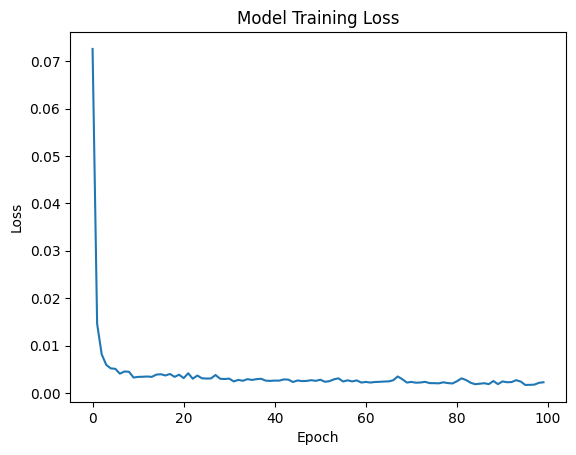

In [26]:
### 4. Building the LSTM Model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Compile and fit the model
regressor.compile(optimizer='adam', loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32)

# Plotting Training Loss
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


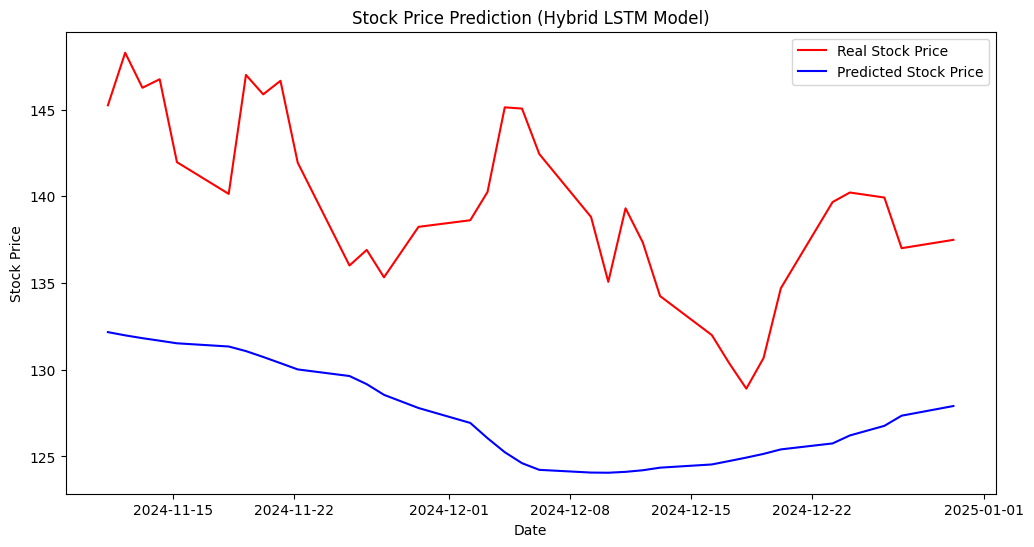

In [27]:
### 5. Making Predictions
# Predict on test data
y_pred = regressor.predict(X_test)

# Rescale predictions and actual values
y_pred_rescaled = sc_lstm.inverse_transform(
    np.hstack((y_pred, np.zeros((y_pred.shape[0], len(['MACD', 'MACD_Signal', 'RA_2', 'RA_20']))))))[:, 0]
y_test_rescaled = sc_lstm.inverse_transform(
    np.hstack((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], len(['MACD', 'MACD_Signal', 'RA_2', 'RA_20']))))))[:, 0]

# Backtesting results
backtesting_results = pd.DataFrame({
    'Date': test_data['Date'].values[60:],
    'Real Price': y_test_rescaled,
    'Predicted Price': y_pred_rescaled
})
backtesting_results.to_csv("Backtesting_Results_Hybrid.csv", index=False)

# Plotting Backtesting Results
plt.figure(figsize=(12, 6))
plt.plot(backtesting_results['Date'], backtesting_results['Real Price'], color='red', label='Real Stock Price')
plt.plot(backtesting_results['Date'], backtesting_results['Predicted Price'], color='blue', label='Predicted Stock Price')
plt.title('Stock Price Prediction (Hybrid LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


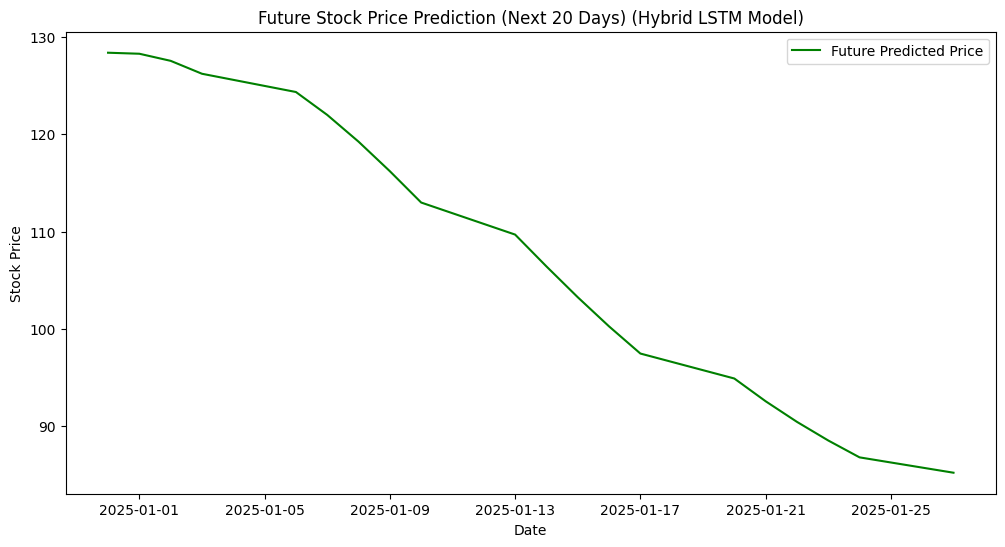

In [28]:
### 6. Future Prediction Logic (20 Days Ahead)
# Start with the last 60 days of the test set
future_input = test_scaled[-60:]
future_predictions = []

for _ in range(20):
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = regressor.predict(future_input)
    future_predictions.append(future_pred[0, 0])
    next_step = np.hstack((future_pred, np.zeros((1, len(['MACD', 'MACD_Signal', 'RA_2', 'RA_20'])))))
    future_input = np.vstack([future_input[0, 1:, :], next_step])

future_predictions_rescaled = sc_lstm.inverse_transform(
    np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((len(future_predictions), len(['MACD', 'MACD_Signal', 'RA_2', 'RA_20']))))))[:, 0]

future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]

future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions_rescaled
})
future_output.to_csv("Future_Predictions_Hybrid.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions_rescaled, color='green', label='Future Predicted Price')
plt.title('Future Stock Price Prediction (Next 20 Days) (Hybrid LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [29]:
### 7. Accuracy Metrics
# Calculate accuracy metrics
trend_real = np.sign(np.diff(y_test_rescaled))
trend_predicted = np.sign(np.diff(y_pred_rescaled))
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

overall_accuracy = 100 - mape

print(f"Trend Accuracy (LSTM Model): {trend_accuracy:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE) (LSTM Model): {mape:.2f}%")
print(f"Overall Accuracy Score (LSTM Model): {overall_accuracy:.2f}%")

Trend Accuracy (LSTM Model): 51.52%
Mean Absolute Percentage Error (MAPE) (LSTM Model): 8.55%
Overall Accuracy Score (LSTM Model): 91.45%
